# Lezione 2 — Dati tabellari clinici, explainability e incertezza

**Modulo 2.** Corso di AI applicata, Zucchetti Centro Sistemi.

Il notebook si esegue dall'alto in basso. Non serve GPU. Tre celle sono marcate
`PUNTO DI VARIAZIONE`: contengono una costante che cambiamo insieme in aula.

### Dati

**UCI Thyroid Disease**, task `sick`: 2.800 righe di training e 972 di test. Sei
esami di laboratorio — TSH, T3, TT4, T4U, FTI, TBG — ciascuno preceduto dal proprio
flag `*_measured`.

> Quinlan J. R. *Thyroid Disease.* UCI Machine Learning Repository, 1987.
> Dati raccolti dal Garavan Institute, Sydney.

Fonte: <https://archive.ics.uci.edu/dataset/102/thyroid+disease>, licenza
[CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).

In [1]:
# Installazione e dati. Su Colab la prima esecuzione impiega circa un minuto.
import importlib, subprocess, sys, io, zipfile, urllib.request, pathlib, warnings
warnings.filterwarnings("ignore")

if importlib.util.find_spec("interpret") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "interpret"], check=True)

D = pathlib.Path("dati/thyroid")
if not (D / "sick.data").exists():
    with urllib.request.urlopen(
        "https://github.com/nunziati/zcs-ai-course-2026/releases/download/"
        "dati-thyroid/uci-thyroid.zip") as r:
        zipfile.ZipFile(io.BytesIO(r.read())).extractall("dati")

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, brier_score_loss, confusion_matrix
plt.rcParams["figure.dpi"] = 110
print("pronto, nessuna GPU richiesta")

pronto, nessuna GPU richiesta


---

# Passo 2 — Dati

In [2]:
# I .data non hanno intestazione, i mancanti sono '?', e l'ultima colonna unisce
# classe e id del record con una barra: "negative.|3733".
COLONNE = ['age', 'sex', 'on_thyroxine', 'query_on_thyroxine',
           'on_antithyroid_medication', 'sick', 'pregnant', 'thyroid_surgery',
           'I131_treatment', 'query_hypothyroid', 'query_hyperthyroid', 'lithium',
           'goitre', 'tumor', 'hypopituitary', 'psych',
           'TSH_measured', 'TSH', 'T3_measured', 'T3', 'TT4_measured', 'TT4',
           'T4U_measured', 'T4U', 'FTI_measured', 'FTI', 'TBG_measured', 'TBG',
           'referral_source', 'target']
ESAMI = ['TSH', 'T3', 'TT4', 'T4U', 'FTI']

def carica(nome):
    d = pd.read_csv(D / nome, header=None, names=COLONNE, na_values="?")
    d["y"] = (d["target"].str.split("|").str[0].str.rstrip(".") == "sick").astype(int)
    return d

train, test = carica("sick.data"), carica("sick.test")
print(f"train {len(train)} righe, {train.y.sum()} positivi ({train.y.mean():.1%})")
print(f"test  {len(test)} righe, {test.y.sum()} positivi ({test.y.mean():.1%})")
train[["age", "sex", "TSH_measured", "TSH", "T3_measured", "T3", "y"]].head()

train 2800 righe, 171 positivi (6.1%)
test  972 righe, 60 positivi (6.2%)


,age,sex,TSH_measured,TSH,T3_measured,T3,y
0,41.0,F,t,1.30,t,2.5,0
1,23.0,F,t,4.10,t,2.0,0
2,46.0,M,t,0.98,f,NaN,0
3,70.0,F,t,0.16,t,1.9,0
4,70.0,F,t,0.72,t,1.2,0


In [3]:
# La cosa strana di questa tabella: se un esame manca, il paziente è quasi sempre sano.
for e in ESAMI:
    manca = train[e].isna()
    print(f"{e:4s}  manca in {manca.sum():4d} righe ({manca.mean():5.1%})"
          f"   prevalenza se manca {train.y[manca].mean():.3f}"
          f"   se misurato {train.y[~manca].mean():.3f}")

print(f"\nprevalenza complessiva: {train.y.mean():.3f}")
print("\nIl verso è il contrario dell'intuizione, e non è un caso: l'esame lo prescrive")
print("un medico che ha già un sospetto. Il fatto che manchi è un'informazione.")

TSH   manca in  284 righe (10.1%)   prevalenza se manca 0.007   se misurato 0.067
T3    manca in  585 righe (20.9%)   prevalenza se manca 0.003   se misurato 0.076
TT4   manca in  184 righe ( 6.6%)   prevalenza se manca 0.000   se misurato 0.065
T4U   manca in  297 righe (10.6%)   prevalenza se manca 0.017   se misurato 0.066
FTI   manca in  295 righe (10.5%)   prevalenza se manca 0.017   se misurato 0.066

prevalenza complessiva: 0.061

Il verso è il contrario dell'intuizione, e non è un caso: l'esame lo prescrive
un medico che ha già un sospetto. Il fatto che manchi è un'informazione.


---

# Passo 3 — Dalla baseline al metodo

In [4]:
# PUNTO DI VARIAZIONE
# Come si trattano i valori mancanti: "mediana", "costante" oppure "nativo".
STRATEGIA_MISSING = "nativo"

def prepara(d):
    """Matrice numerica. I mancanti restano NaN."""
    X = d[["age"] + ESAMI].copy()
    X["sex"] = np.where(d["sex"].isna(), np.nan, (d["sex"] == "F").astype(float))
    for c in ['on_thyroxine', 'sick', 'pregnant', 'thyroid_surgery', 'query_hypothyroid',
              'query_hyperthyroid', 'goitre', 'tumor', 'psych']:
        X[c] = (d[c] == "t").astype(float)
    return X

X_train, X_test = prepara(train), prepara(test)
y_train, y_test = train.y.values, test.y.values

if STRATEGIA_MISSING != "nativo":
    riempi = X_train.median() if STRATEGIA_MISSING == "mediana" else -1
    X_train, X_test = X_train.fillna(riempi), X_test.fillna(riempi)

print(f"{X_train.shape[1]} colonne, strategia sui mancanti: {STRATEGIA_MISSING}")

16 colonne, strategia sui mancanti: nativo


In [5]:
# Tre modelli, sullo stesso split ufficiale. Cambia solo come trattano i mancanti.
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

grezzo = prepara(train), prepara(test)
for nome, riempi in [("logistica, imputa con la mediana", grezzo[0].median()),
                     ("logistica, imputa con -1", -1)]:
    m = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
    m.fit(grezzo[0].fillna(riempi), y_train)
    p = m.predict_proba(grezzo[1].fillna(riempi))[:, 1]
    print(f"{nome:34s} AUC {roc_auc_score(y_test, p):.4f}")

albero = HistGradientBoostingClassifier(random_state=0).fit(X_train, y_train)
p_albero = albero.predict_proba(X_test)[:, 1]
print(f"{'albero, tiene i NaN come sono':34s} AUC {roc_auc_score(y_test, p_albero):.4f}")

print("\nCambiare solo l'imputazione costa alla logistica venti punti di AUC.")
print("L'albero non imputa: tratta 'manca' come un valore a sé, ed è quello che serve.")

logistica, imputa con la mediana   AUC 0.9637
logistica, imputa con -1           AUC 0.7747


albero, tiene i NaN come sono      AUC 0.9967

Cambiare solo l'imputazione costa alla logistica venti punti di AUC.
L'albero non imputa: tratta 'manca' come un valore a sé, ed è quello che serve.


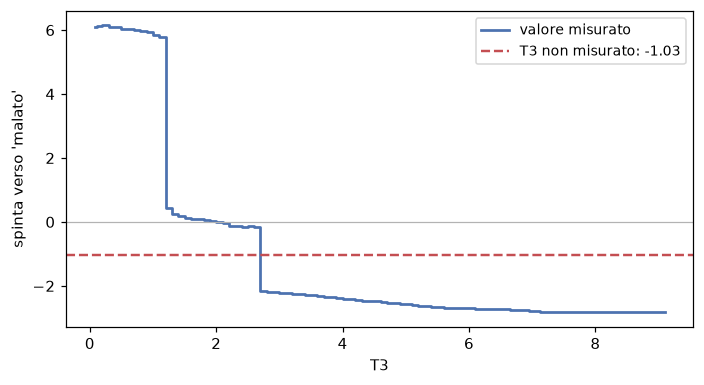

AUC dell'EBM: 0.9833

T3 basso spinge forte verso 'malato'. T3 non misurato spinge nella direzione
opposta, e il modello lo stima invece di ereditarlo da una scelta di imputazione.


In [6]:
# L'EBM impara una curva per ogni feature, e si possono guardare una per una.
from interpret.glassbox import ExplainableBoostingClassifier

ebm = ExplainableBoostingClassifier(random_state=0, interactions=0).fit(X_train, y_train)
i = ebm.term_names_.index("T3")
punteggi, tagli = ebm.term_scores_[i][1:-1], np.asarray(ebm.bins_[i][0], float)

fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.step(np.append(tagli, tagli[-1] + np.diff(tagli).mean()), punteggi,
        where="mid", color="#4c72b0", lw=1.8, label="valore misurato")
ax.axhline(ebm.term_scores_[i][0], color="#c44e52", ls="--", lw=1.6,
           label=f"T3 non misurato: {ebm.term_scores_[i][0]:+.2f}")
ax.axhline(0, color="0.7", lw=0.8)
ax.set_xlabel("T3"); ax.set_ylabel("spinta verso 'malato'"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f"AUC dell'EBM: {roc_auc_score(y_test, ebm.predict_proba(X_test)[:, 1]):.4f}")
print("\nT3 basso spinge forte verso 'malato'. T3 non misurato spinge nella direzione")
print("opposta, e il modello lo stima invece di ereditarlo da una scelta di imputazione.")

---

# Passo 4 — Valutazione

In [7]:
# Il numero che si porterebbe in riunione.
print(f"AUC sul test ufficiale: {roc_auc_score(y_test, p_albero):.4f}")

(vn, fp), (fn, vp) = confusion_matrix(y_test, (p_albero >= 0.5).astype(int))
print(f"\nalla soglia 0,5:")
print(f"  veri negativi  {vn:4d}     falsi positivi {fp:4d}")
print(f"  falsi negativi {fn:4d}     veri positivi  {vp:4d}")
print(f"\nsensibilità {vp / (vp + fn):.3f}: il modello lascia passare {fn} malati su {vp + fn}.")
print("Discriminare bene e essere utili sono due domande diverse.")

AUC sul test ufficiale: 0.9967

alla soglia 0,5:
  veri negativi   906     falsi positivi    6
  falsi negativi   10     veri positivi    50

sensibilità 0.833: il modello lascia passare 10 malati su 60.
Discriminare bene e essere utili sono due domande diverse.


In [8]:
# Perché quell'AUC è così alto. Un albero con due sole domande, su due soli esami.
from sklearn.tree import DecisionTreeClassifier, export_text

tr = train[train.T3.notna()]
piccolo = DecisionTreeClassifier(max_depth=2, random_state=0).fit(tr[["T3", "TT4"]], tr.y)
print(export_text(piccolo, feature_names=["T3", "TT4"], show_weights=True))

foglie = piccolo.apply(tr[["T3", "TT4"]].values)
for f in np.unique(foglie):
    m = foglie == f
    print(f"foglia {f}: {m.sum():4d} righe, {tr.y.values[m].sum():3d} malati, "
          f"prevalenza {tr.y.values[m].mean():.3f}")

print("\nUna foglia sola contiene 145 dei 169 malati. La classe positiva di questo")
print("dataset si definisce in clinica a partire dai valori di laboratorio: il modello")
print("sta imparando la definizione della diagnosi, non a prevederla.")
print("Prima di festeggiare un AUC, chiedersi chi ha scritto l'etichetta e con cosa.")

|--- T3 <= 1.15
|   |--- TT4 <= 53.00
|   |   |--- weights: [39.00, 4.00] class: 0
|   |--- TT4 >  53.00
|   |   |--- weights: [30.00, 145.00] class: 1
|--- T3 >  1.15
|   |--- TT4 <= 156.50
|   |   |--- weights: [1811.00, 5.00] class: 0
|   |--- TT4 >  156.50
|   |   |--- weights: [166.00, 15.00] class: 0

foglia 2:   43 righe,   4 malati, prevalenza 0.093
foglia 3:  175 righe, 145 malati, prevalenza 0.829
foglia 5: 1816 righe,   5 malati, prevalenza 0.003
foglia 6:  181 righe,  15 malati, prevalenza 0.083

Una foglia sola contiene 145 dei 169 malati. La classe positiva di questo
dataset si definisce in clinica a partire dai valori di laboratorio: il modello
sta imparando la definizione della diagnosi, non a prevederla.
Prima di festeggiare un AUC, chiedersi chi ha scritto l'etichetta e con cosa.


albero contro LightGBM   differenza +0.0002  intervallo [-0.0009, +0.0012]   indistinguibili


albero contro EBM        differenza +0.0130  intervallo [+0.0052, +0.0239]   diversi davvero


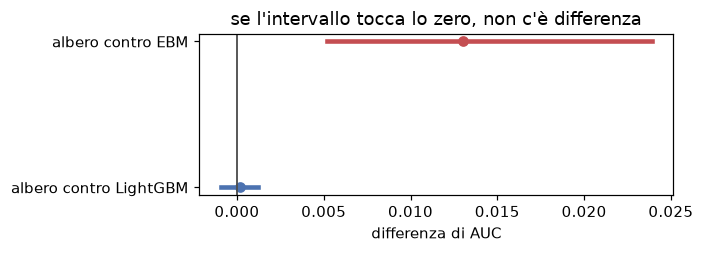


Il primo intervallo attraversa lo zero: quei due modelli non si distinguono,
e scegliere il 'migliore' vuol dire scegliere il rumore. Il secondo sta tutto
da una parte: quella differenza c'è, ed è il prezzo delle curve leggibili.


In [9]:
# Con 60 malati nel test, quando due modelli sono davvero diversi?
import lightgbm as lgb
from interpret.glassbox import ExplainableBoostingClassifier

p_lgbm = lgb.LGBMClassifier(verbose=-1, random_state=0).fit(X_train, y_train) \
            .predict_proba(X_test)[:, 1]
p_ebm = ebm.predict_proba(X_test)[:, 1]

def differenza(a, b, ripetizioni=1000):
    """Ripesca il test a caso mille volte e guarda la differenza di AUC ogni volta."""
    rng = np.random.default_rng(0)
    d = [roc_auc_score(y_test[s], a[s]) - roc_auc_score(y_test[s], b[s])
         for s in (rng.choice(len(y_test), len(y_test), True) for _ in range(ripetizioni))
         if y_test[s].sum() > 1]
    return np.mean(d), np.percentile(d, [2.5, 97.5])

confronti = [("albero contro LightGBM", p_albero, p_lgbm),
             ("albero contro EBM", p_albero, p_ebm)]

fig, ax = plt.subplots(figsize=(6.5, 2.4))
for k, (nome, a, b) in enumerate(confronti):
    media, (lo, hi) = differenza(a, b)
    separato = lo * hi > 0
    ax.plot([lo, hi], [k, k], lw=3, color="#c44e52" if separato else "#4c72b0")
    ax.plot(media, k, "o", color="#c44e52" if separato else "#4c72b0")
    print(f"{nome:24s} differenza {media:+.4f}  intervallo [{lo:+.4f}, {hi:+.4f}]"
          f"   {'diversi davvero' if separato else 'indistinguibili'}")

ax.axvline(0, color="0.3", lw=1.2)
ax.set_yticks(range(len(confronti))); ax.set_yticklabels([c[0] for c in confronti])
ax.set_xlabel("differenza di AUC"); ax.set_title("se l'intervallo tocca lo zero, non c'è differenza")
plt.tight_layout(); plt.show()

print("\nIl primo intervallo attraversa lo zero: quei due modelli non si distinguono,")
print("e scegliere il 'migliore' vuol dire scegliere il rumore. Il secondo sta tutto")
print("da una parte: quella differenza c'è, ed è il prezzo delle curve leggibili.")

               righe  il modello dice  malati  in realtà sono
(-0.001, 0.2]    910            0.001       7           0.008
(0.2, 0.4]         4            0.306       3           0.750
(0.4, 0.6]         6            0.511       3           0.500
(0.6, 0.8]         5            0.684       3           0.600
(0.8, 1.0]        47            0.969      44           0.936


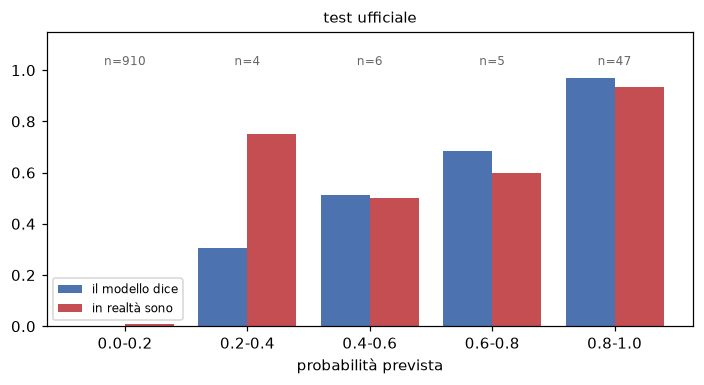


Brier: 0.0132  (più è basso, meglio è)

Le due barre sono vicine in ogni intervallo: qui il modello è calibrato.
Attenzione ai conteggi in alto: negli intervalli di mezzo ci sono quattro o
cinque pazienti, quindi quelle barre non vogliono dire granché.


In [10]:
# Calibrare vuol dire: quando il modello dice 30%, i malati sono davvero il 30%?
# Si controlla dividendo le probabiltà in intervalli e contando dentro ognuno.
BORDI = [0, 0.2, 0.4, 0.6, 0.8, 1.0]

def bin_di_probabilita(y, p):
    g = pd.DataFrame({"y": y, "p": p}).groupby(pd.cut(p, BORDI, include_lowest=True),
                                               observed=False)
    return pd.DataFrame({"righe": g.size(), "il modello dice": g.p.mean(),
                         "malati": g.y.sum(), "in realtà sono": g.y.mean()})

def disegna_bin(ax, tabella, titolo):
    x = np.arange(len(tabella))
    ax.bar(x - 0.2, tabella["il modello dice"], 0.4, color="#4c72b0", label="il modello dice")
    ax.bar(x + 0.2, tabella["in realtà sono"], 0.4, color="#c44e52", label="in realtà sono")
    for i, n in enumerate(tabella["righe"]):
        ax.text(i, 1.02, f"n={n}", ha="center", fontsize=8, color="0.4")
    ax.set_xticks(x); ax.set_xticklabels([f"{a:.1f}-{b:.1f}" for a, b in zip(BORDI, BORDI[1:])])
    ax.set_ylim(0, 1.15); ax.set_title(titolo, fontsize=10)
    ax.set_xlabel("probabilità prevista"); ax.legend(fontsize=8)

tabella = bin_di_probabilita(y_test, p_albero)
print(tabella.round(3).to_string())

fig, ax = plt.subplots(figsize=(6.5, 3.6))
disegna_bin(ax, tabella, "test ufficiale")
plt.tight_layout(); plt.show()

print(f"\nBrier: {brier_score_loss(y_test, p_albero):.4f}  (più è basso, meglio è)")
print("\nLe due barre sono vicine in ogni intervallo: qui il modello è calibrato.")
print("Attenzione ai conteggi in alto: negli intervalli di mezzo ci sono quattro o")
print("cinque pazienti, quindi quelle barre non vogliono dire granché.")

nel training senza SVI i malati sono il 1.6%, in SVI il 18.3%

               righe  il modello dice  malati  in realtà sono
(-0.001, 0.2]    244            0.002      34           0.139
(0.2, 0.4]         5            0.275       3           0.600
(0.4, 0.6]         2            0.502       1           0.500
(0.6, 0.8]         2            0.707       1           0.500
(0.8, 1.0]        10            0.983       9           0.900


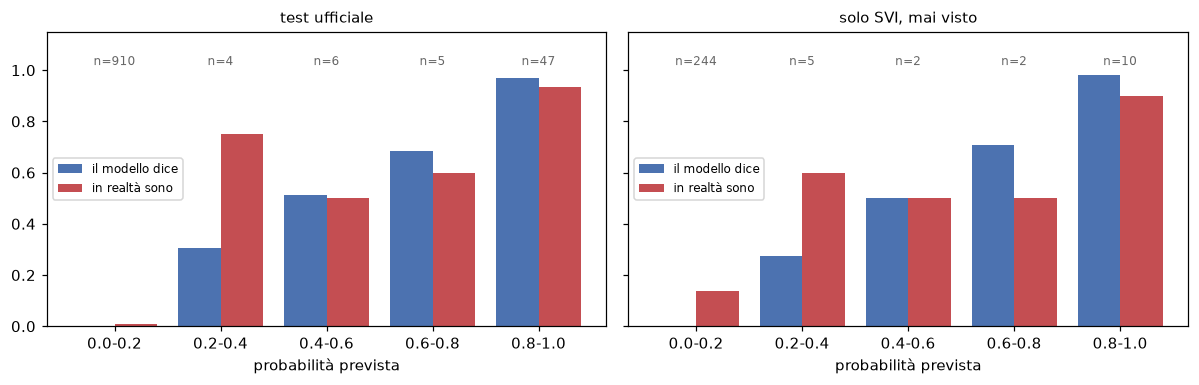

AUC   sul test 0.9967   su SVI 0.9276
Brier sul test 0.0132   su SVI 0.1407

Guarda il primo intervallo a destra: il modello dice 0,00 e i malati sono il 14%.
L'ordine dei pazienti regge, l'AUC scende di poco. Le probabilità no: sono
sbagliate di un fattore dieci. È quasi sempre questo, quando un modello
'smette di funzionare' dopo che è andato in produzione.


In [11]:
# PUNTO DI VARIAZIONE
# Il centro tenuto fuori dall'addestramento, per vedere cosa succede altrove.
CENTRO_ESCLUSO = "SVI"

fuori = (train.referral_source != CENTRO_ESCLUSO).values
dentro = (test.referral_source == CENTRO_ESCLUSO).values

altrove = HistGradientBoostingClassifier(random_state=0).fit(X_train[fuori], y_train[fuori])
p_altrove = altrove.predict_proba(X_test[dentro])[:, 1]
y_altrove = y_test[dentro]

print(f"nel training senza {CENTRO_ESCLUSO} i malati sono il {y_train[fuori].mean():.1%}, "
      f"in {CENTRO_ESCLUSO} il {y_altrove.mean():.1%}\n")
print(bin_di_probabilita(y_altrove, p_altrove).round(3).to_string())

fig, assi = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
disegna_bin(assi[0], bin_di_probabilita(y_test, p_albero), "test ufficiale")
disegna_bin(assi[1], bin_di_probabilita(y_altrove, p_altrove), f"solo {CENTRO_ESCLUSO}, mai visto")
plt.tight_layout(); plt.show()

print(f"AUC   sul test {roc_auc_score(y_test, p_albero):.4f}   "
      f"su {CENTRO_ESCLUSO} {roc_auc_score(y_altrove, p_altrove):.4f}")
print(f"Brier sul test {brier_score_loss(y_test, p_albero):.4f}   "
      f"su {CENTRO_ESCLUSO} {brier_score_loss(y_altrove, p_altrove):.4f}")
print("\nGuarda il primo intervallo a destra: il modello dice 0,00 e i malati sono il 14%.")
print("L'ordine dei pazienti regge, l'AUC scende di poco. Le probabilità no: sono")
print("sbagliate di un fattore dieci. È quasi sempre questo, quando un modello")
print("'smette di funzionare' dopo che è andato in produzione.")

In [12]:
# PUNTO DI VARIAZIONE
# Quanto costa non vedere un malato, rispetto a un allarme sbagliato.
COSTO_FN_SU_FP = 10

print(f"{'costo FN/FP':>12s} {'soglia':>8s} {'malati visti':>13s} "
      f"{'malati persi':>13s} {'falsi allarmi':>14s}")
for rapporto in (1, 5, 10, 20, 50):
    s = 1 / (1 + rapporto)
    vp = int(((p_albero >= s) & (y_test == 1)).sum())
    fn = int(((p_albero < s) & (y_test == 1)).sum())
    fp = int(((p_albero >= s) & (y_test == 0)).sum())
    print(f"{rapporto:>12d} {s:>8.3f} {vp:>13d} {fn:>13d} {fp:>14d}"
          f"{'   <--' if rapporto == COSTO_FN_SU_FP else ''}")

print("\nNon esiste la soglia giusta in astratto: esiste quella che corrisponde al")
print("rapporto di costo che si è deciso. Massimizzare F1 non evita questa scelta,")
print("la fa di nascosto. Qui almeno il numero è scritto in cima alla cella.")

 costo FN/FP   soglia  malati visti  malati persi  falsi allarmi
           1    0.500            50            10              6
           5    0.167            54             6             10
          10    0.091            55             5             12   <--
          20    0.048            57             3             14
          50    0.020            58             2             15

Non esiste la soglia giusta in astratto: esiste quella che corrisponde al
rapporto di costo che si è deciso. Massimizzare F1 non evita questa scelta,
la fa di nascosto. Qui almeno il numero è scritto in cima alla cella.


---

## Cosa resta

Quattro cose, in ordine.

**Il missing è informativo, e nel verso contrario a quello che ci si aspetta.** Un
esame che manca dice che il paziente sta bene, perché a prescriverlo è un medico che
ha già un sospetto. L'albero lo usa, la logistica con l'imputazione lo perde.

**Un AUC di 0,997 va guardato con sospetto, non con soddisfazione.** Qui misura come
è stata costruita l'etichetta: due domande su due esami bastano a raccogliere 145 dei
169 malati. E alla soglia 0,5 restano comunque dieci malati non visti su sessanta.

**Fra due modelli, la differenza va misurata insieme al suo intervallo.** Con sessanta
malati nel test, due modelli che sembrano diversi spesso non lo sono.

**L'ordine dei pazienti e la probabilità stampata sono due cose separate, e si
rompono separatamente.** Cambiando centro di provenienza, l'ordine regge e le
probabilità no: il modello dice 0,00 dove i malati sono il 14%.

**La domanda per la sessione delle 12:30**: nei dati di laboratorio di ZCS, chi produce
l'etichetta, con quali misure, e quelle misure finiscono anche fra le feature?